# 여러가지 확률분포

### Penguins 데이터셋을 사용하여 “펭귄의 날개 길이는 정규분포일까”를 확인

• 데이터 분석 포인트

– 전체 펭귄들에 대한 flipper_length_mm(날개 길이)의 분포를 시각화

– 전체 펭귄 날개 길이의 평균/표준편차 계산

– 자신의 날개 길이가 210mm인 펭귄이 있다고 가정할 때, 이 펭귄의 Z-점수를 구하고, 이 펭
귄보다 날개가 긴 펭귄은 전체의 몇 %인지 계산

– 펭귄 종 별로 날개 길이의 평균/표준편차 계산 및 분포 시각화

- Palmer Penguins 데이터셋으로, 남극의 3종의 펭귄(Adelie, Chinstrap, Gentoo)의 신체 측정
값을 포함

평균: 200.97mm, 표준편차: 14.02mm
210mm 펭귄의 Z-score: 0.64
이 펭귄보다 날개가 긴 비율: 25.96%


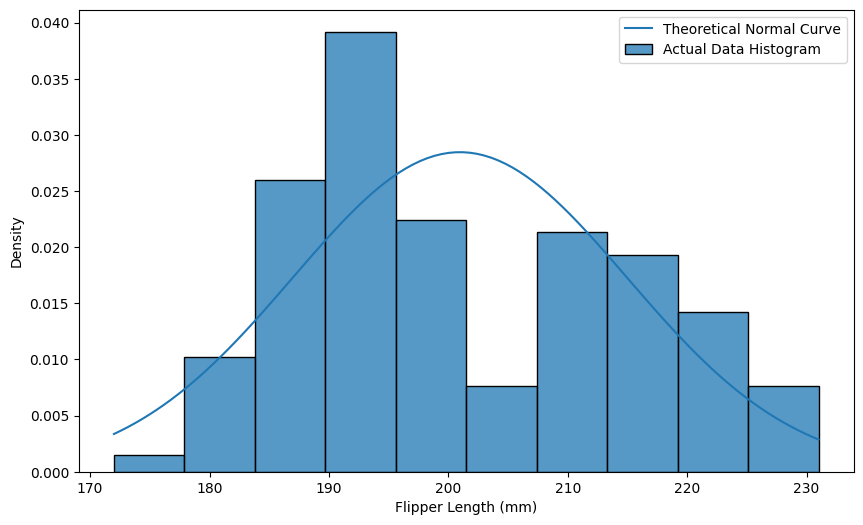

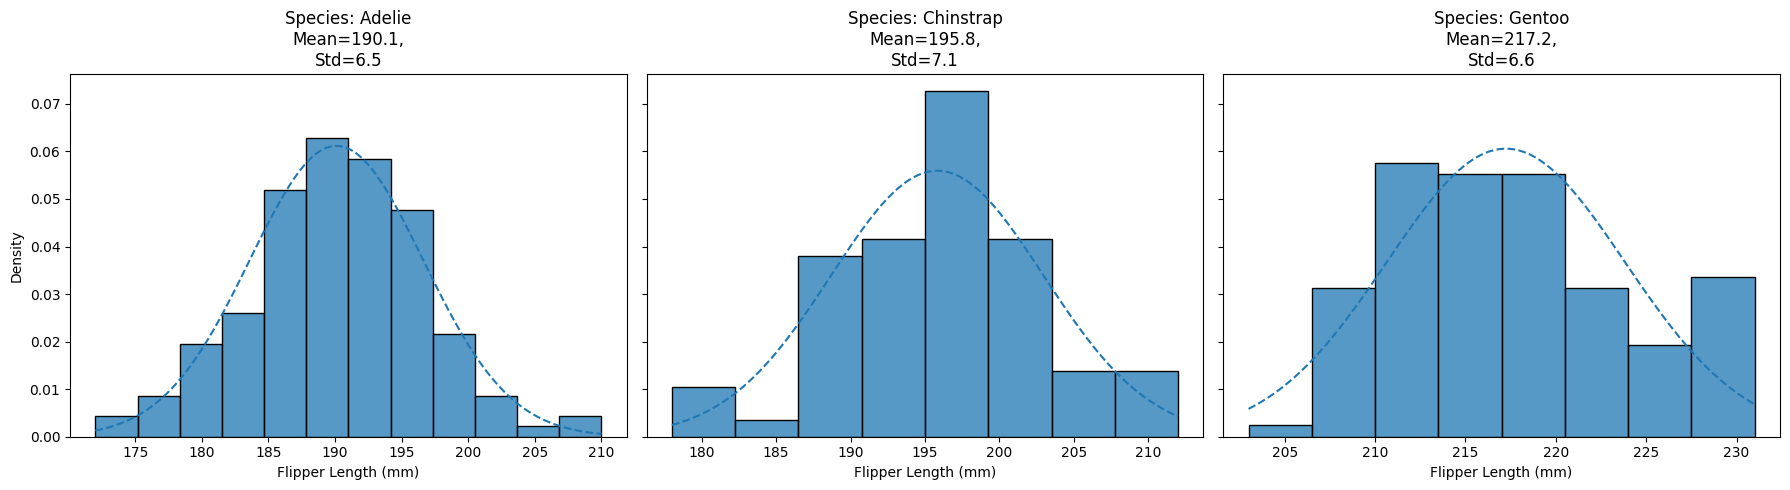

In [13]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# penguins 데이터에서 결측치 제거 후 flipper_length_mm 컬럼만 추출
flipper = sns.load_dataset('penguins').dropna()['flipper_length_mm']

# 평균과 표준편차 계산
mu = flipper.mean()
sigma = flipper.std()

# 히스토그램 그리기
plt.figure(figsize=(10, 6))
sns.histplot(flipper, stat='density', label='Actual Data Histogram')

# 정규분포 곡선 그리기 위한 x값 생성
x_range = np.linspace(flipper.min(), flipper.max(), 100)

# 이론적인 정규분포 PDF 계산
norm_pdf = stats.norm.pdf(x_range, loc=mu, scale=sigma)

# 정규분포 곡선 그리기
plt.plot(x_range, norm_pdf, label='Theoretical Normal Curve')

# x축 라벨 및 범례 표시
plt.xlabel('Flipper Length (mm)')
plt.legend()

# 이미지 저장
plt.savefig('ex2_1_res.png')

# Z-score 계산 (210mm인 펭귄 기준)
z_score = (210 - mu) / sigma

# 해당 값보다 클 확률 (생존함수 sf 사용)
prob_longer = stats.norm.sf(z_score)

# 결과 출력
print(f"평균: {mu:.2f}mm, 표준편차: {sigma:.2f}mm")
print(f"210mm 펭귄의 Z-score: {z_score:.2f}")
print(f"이 펭귄보다 날개가 긴 비율: {prob_longer * 100:.2f}%")

# 전체 데이터 다시 불러오기 (species별 분석용)
df = sns.load_dataset('penguins').dropna()

# 종 목록 추출
species_list = df['species'].unique()

# 1행 3열 subplot 생성 (종 3개)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 각 종별로 반복
for i, species in enumerate(species_list):

    # 해당 종의 flipper 길이 데이터 추출
    data = df[df['species'] == species]['flipper_length_mm']

    # 히스토그램 (density 기준)
    sns.histplot(data, stat='density', ax=axes[i])

    # 평균과 표준편차 계산
    mu = data.mean()
    sigma = data.std()

    # x값 생성
    x_range = np.linspace(data.min(), data.max(), 100)

    # 정규분포 PDF 계산 (오타 수정: x_raange → x_range)
    norm_pdf = stats.norm.pdf(x_range, loc=mu, scale=sigma)

    # 정규분포 곡선 추가
    axes[i].plot(x_range, norm_pdf, linestyle='--')

    # 제목과 x축 라벨 설정
    axes[i].set_title(f'Species: {species}\nMean={mu:.1f},\nStd={sigma:.1f}')
    axes[i].set_xlabel('Flipper Length (mm)')

# subplot 간격 자동 조정
plt.tight_layout()

# 이미지 저장
plt.savefig('ex2_1_res2.png')

# 그래프 출력
plt.show()

- 펭귄 데이터셋에서 날개 길이를 보면 전체적으로 종 모양의 분포를 보여 정규분포와 비슷한 형태를
가진다. 평균은 약 200.97mm, 표준편차는 14.02mm로 대부분의 값이 이 주변에 모여 있다.
-  다만
그래프를 보면 완전히 대칭적이지는 않아 완벽한 정규분포라고 보기는 어렵다.

종별로 보면 차이가 더
잘 보인다.
Adelie는 평균이 약 190mm로 짧고,

Chinstrap은 약 196mm, Gentoo는 약 217mm로 가장
길다.

 각 종 안에서는 정규분포에 가깝지만, 서로 평균이 달라서 전체를 합치면 분포가 살짝 섞인
형태가 된다

결론:  따라서 펭귄의 날개 길이는 **전체적으로는 정규분포에 가깝지만,** **종별로 나눠서 보는
것이 더 정확**하다.